# LLaVA-Med closed-question analysis

This notebook analyzes **LLaVA-Med** on **SLAKE closed (Yes/No) questions** using the **raw closed files**.

The analysis focuses on prompt sensitivity, consensus vs non-consensus behavior, single vs multi prompting, emotion effects, role effects, and direct-vs-indirect phrasing effects.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_NAME = "LLaVA-Med"
MODEL_PREFIX = "llavamed"
INPUT_DIR = Path("output/phase_2/LLaVA-Med")
DATASET = "SLAKE"
ONLY_CLOSED = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
def parse_answer(text):
    if text is None:
        return "Undecided"

    text = str(text).strip()
    text_lower = text.lower()

    if text.startswith("Yes"):
        return "Yes"
    if text.startswith("No"):
        return "No"

    has_yes = "yes" in text_lower
    has_no = "no" in text_lower

    if has_yes and has_no:
        return "Undecided"
    if has_yes:
        return "Yes"
    if has_no:
        return "No"
    return "Undecided"


def compute_metrics(preds, gts):
    yes = sum(p == "Yes" for p in preds)
    no = sum(p == "No" for p in preds)
    undecided = sum(p == "Undecided" for p in preds)

    tp = sum((p == "Yes") and (g == "Yes") for p, g in zip(preds, gts))
    fp = sum((p == "Yes") and (g == "No") for p, g in zip(preds, gts))
    tn = sum((p == "No") and (g == "No") for p, g in zip(preds, gts))
    fn = sum((p == "No") and (g == "Yes") for p, g in zip(preds, gts))

    total = len(preds)
    # Strict closed-question accuracy: Undecided counts as incorrect
    acc = (tp + tn) / total if total else 0.0

    return {
        "yes": yes,
        "no": no,
        "undecided": undecided,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "acc": acc,
        "total": total,
    }


def parse_prefix(prefix):
    name = prefix.replace("eval_", "")
    core = name[len(f"{MODEL_PREFIX}_"): ]
    core = core[:-len("_closed")] if core.endswith("_closed") else core

    parts = core.split("_")
    dataset = parts[0]
    conv_mode = parts[1]
    emotion = "_".join(parts[2:])

    return {
        "dataset": dataset,
        "conv_mode": conv_mode,
        "emotion": emotion,
    }


label_map = {
    "default": "default",
    "direct_clinician_neutral": "clin_neutral_dir",
    "direct_clinician_fear_anxiety": "clin_fear_dir",
    "direct_clinician_anger_frustration": "clin_anger_dir",
    "direct_clinician_sadness_distress": "clin_sad_dir",
    "direct_patient_neutral": "pat_neutral_dir",
    "direct_patient_fear_anxiety": "pat_fear_dir",
    "direct_patient_anger_frustration": "pat_anger_dir",
    "direct_patient_sadness_distress": "pat_sad_dir",
    "indirect_clinician_neutral": "clin_neutral_Indir",
    "indirect_clinician_fear_anxiety": "clin_fear_Indir",
    "indirect_clinician_anger_frustration": "clin_anger_Indir",
    "indirect_clinician_sadness_distress": "clin_sad_Indir",
    "indirect_patient_neutral": "pat_neutral_Indir",
    "indirect_patient_fear_anxiety": "pat_fear_Indir",
    "indirect_patient_anger_frustration": "pat_anger_Indir",
    "indirect_patient_sadness_distress": "pat_sad_Indir",
}

row_order = [
    "default",
    "clin_neutral_dir", "clin_fear_dir", "clin_anger_dir", "clin_sad_dir",
    "pat_neutral_dir", "pat_fear_dir", "pat_anger_dir", "pat_sad_dir",
    "clin_neutral_Indir", "clin_fear_Indir", "clin_anger_Indir", "clin_sad_Indir",
    "pat_neutral_Indir", "pat_fear_Indir", "pat_anger_Indir", "pat_sad_Indir",
]
multi_row_order = [x for x in row_order if x != "default"]


def prompt_style(emotion):
    if emotion == "default":
        return "default"
    return "direct" if emotion.startswith("direct_") else "indirect"


def prompt_role(emotion):
    if emotion == "default":
        return "default"
    return "clinician" if "_clinician_" in emotion else "patient"


def prompt_emotion(emotion):
    if emotion == "default":
        return "default"
    if "neutral" in emotion:
        return "neutral"
    if "fear_anxiety" in emotion:
        return "fear"
    if "anger_frustration" in emotion:
        return "anger"
    if "sadness_distress" in emotion:
        return "sad"
    return "other"


def build_similarity_matrix(df, prompt_columns):
    sim = pd.DataFrame(index=prompt_columns, columns=prompt_columns, dtype=float)
    for p1 in prompt_columns:
        for p2 in prompt_columns:
            sim.loc[p1, p2] = (df[p1] == df[p2]).mean()
    return sim


def plot_similarity_heatmap(mat, title, figsize=(12, 10), fontsize=9):
    plt.figure(figsize=figsize)
    plt.imshow(mat.astype(float), aspect="auto")
    plt.colorbar(label="Similarity")
    plt.xticks(
        ticks=range(len(mat.columns)),
        labels=mat.columns,
        rotation=90
    )
    plt.yticks(
        ticks=range(len(mat.index)),
        labels=mat.index
    )
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=fontsize)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def mean_off_diagonal(mat):
    vals = mat.astype(float).values
    n = vals.shape[0]
    off_diag = vals[~np.eye(n, dtype=bool)]
    return off_diag.mean()


def yes_rate(yes, total):
    if pd.isna(total) or total == 0:
        return np.nan
    return yes / total


def undecided_rate(undecided, total):
    if pd.isna(total) or total == 0:
        return np.nan
    return undecided / total


def get_metric(df, prompt, col):
    return df.loc[df["prompt"] == prompt, col].iloc[0]

In [3]:
rows = []
all_preds = {}
all_gts = None

pattern = f"{MODEL_PREFIX}_{DATASET}_*_closed.jsonl" if ONLY_CLOSED else f"{MODEL_PREFIX}_{DATASET}_*.jsonl"

for file in sorted(INPUT_DIR.glob(pattern)):
    if file.name.startswith("eval_"):
        continue

    preds = []
    gts = []

    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item["model_answer"]))
            gts.append(item["answer"])

    prefix = file.stem
    metrics = compute_metrics(preds, gts)
    metrics["prefix"] = prefix
    rows.append(metrics)

    all_preds[prefix] = preds
    if all_gts is None:
        all_gts = gts

result_df = pd.DataFrame(rows)
meta_df = pd.DataFrame([parse_prefix(x) for x in result_df["prefix"]])
result_df = pd.concat([meta_df, result_df], axis=1)

result_df["prompt"] = result_df["emotion"].map(label_map)
result_df["style"] = result_df["emotion"].apply(prompt_style)
result_df["role"] = result_df["emotion"].apply(prompt_role)
result_df["affect"] = result_df["emotion"].apply(prompt_emotion)

summary_df = result_df[[
    "dataset", "conv_mode", "emotion", "prompt", "style", "role", "affect",
    "total", "yes", "no", "undecided", "acc"
]].copy()

summary_df = summary_df.sort_values(["conv_mode", "emotion"]).reset_index(drop=True)

wide_table = summary_df.pivot(
    index="prompt",
    columns="conv_mode",
    values=["total", "yes", "no", "undecided", "acc"]
)

wide_table = wide_table.swaplevel(0, 1, axis=1)
wide_table = wide_table[
    [
        ("single", "total"),
        ("single", "yes"),
        ("single", "no"),
        ("single", "undecided"),
        ("multi", "total"),
        ("multi", "yes"),
        ("multi", "no"),
        ("multi", "undecided"),
        ("single", "acc"),
        ("multi", "acc"),
    ]
]

wide_table.columns = [
    "single_Total", "single_Yes", "single_No", "single_Undecided",
    "multi_Total", "multi_Yes", "multi_No", "multi_Undecided",
    "single_Acc", "multi_Acc"
]

wide_table = wide_table.reset_index()
wide_table["prompt"] = pd.Categorical(wide_table["prompt"], categories=row_order, ordered=True)
wide_table = wide_table.sort_values("prompt").reset_index(drop=True)

int_cols = [
    "single_Total", "single_Yes", "single_No", "single_Undecided",
    "multi_Total", "multi_Yes", "multi_No", "multi_Undecided",
]
for col in int_cols:
    wide_table[col] = wide_table[col].astype("Int64")

wide_table["single_Acc"] = wide_table["single_Acc"].round(3)
wide_table["multi_Acc"] = wide_table["multi_Acc"].round(3)

print(f"Loaded {len(result_df)} prompt files.")
print(f"Samples per file: {result_df['total'].iloc[0]}")
wide_table

Loaded 33 prompt files.
Samples per file: 355


,prompt,single_Total,single_Yes,single_No,single_Undecided,multi_Total,multi_Yes,multi_No,multi_Undecided,single_Acc,multi_Acc
0,default,355,230,125,0,<NA>,<NA>,<NA>,<NA>,0.631,NaN
1,clin_neutral_dir,355,262,93,0,355,240,115,0,0.575,0.603
2,clin_fear_dir,355,273,81,1,355,251,104,0,0.623,0.639
3,clin_anger_dir,355,263,91,1,355,238,117,0,0.637,0.654
4,clin_sad_dir,355,234,103,18,355,237,118,0,0.628,0.656
5,pat_neutral_dir,355,259,92,4,355,241,114,0,0.566,0.606
6,pat_fear_dir,355,279,70,6,355,245,110,0,0.583,0.623
7,pat_anger_dir,355,260,92,3,355,240,115,0,0.577,0.608
8,pat_sad_dir,355,264,81,10,355,237,118,0,0.597,0.645
9,clin_neutral_Indir,355,244,111,0,355,233,122,0,0.552,0.561


## Basic prompt-level performance

The table above summarizes LLaVA-Med performance on **SLAKE closed yes/no questions** across all prompt conditions.

Each row corresponds to one prompt variant, and the columns report:

- **single_Total / multi_Total**: total number of closed questions
- **single_Yes / multi_Yes**: number of predicted Yes answers
- **single_No / multi_No**: number of predicted No answers
- **single_Undecided / multi_Undecided**: number of responses that could not be parsed as a strict Yes/No answer
- **single_Acc / multi_Acc**: strict closed-question accuracy, where **Undecided** counts as incorrect

Initial observations:

- **Multi-turn prompting generally improves accuracy**, but the gains are modest.
- LLaVA-Med shows a strong overall **Yes-bias**, especially in **single-turn** mode.
- A small but important number of **single-turn** outputs are **Undecided**, which means the model sometimes fails to follow the closed yes/no format and produces free-text answers instead.
- The largest single-turn undecided counts appear in:
  - `clin_sad_dir` = **18**
  - `clin_sad_Indir` = **15**
  - `pat_sad_dir` = **10**
- In contrast, **multi-turn prompting eliminates Undecided outputs** in the current results.
- The **default** prompt exists only in **single-turn** mode, so its multi-turn values are empty by design.

This table provides the main per-prompt summary before moving to deeper analyses such as consensus, similarity, emotion effects, role effects, and direct-vs-indirect comparisons.

## Consensus vs non-consensus setup

Consensus is computed over the parsed closed-answer labels (**Yes / No / Undecided**) across all prompt variants for the same sample.

- **Consensus sample**: all prompt variants produce the same parsed label
- **Non-consensus sample**: at least two prompt variants disagree

Because **Undecided** is kept as a valid parsed outcome, these statistics capture both answer changes and closed-format failures.


In [4]:

merged_df = None

for prefix, preds in all_preds.items():
    temp_df = pd.DataFrame({
        "sample_id": range(len(preds)),
        prefix: preds,
    })
    merged_df = temp_df if merged_df is None else merged_df.merge(temp_df, on="sample_id")

merged_df["ground_truth"] = all_gts
prompt_columns = [c for c in merged_df.columns if c not in ["sample_id", "ground_truth"]]
merged_df["consensus"] = merged_df[prompt_columns].nunique(axis=1) == 1

non_consensus_df = merged_df[~merged_df["consensus"]].copy()

rows_nc = []
for prefix in prompt_columns:
    preds_nc = non_consensus_df[prefix].tolist()
    gts_nc = non_consensus_df["ground_truth"].tolist()
    metrics = compute_metrics(preds_nc, gts_nc)
    metrics["prefix"] = prefix
    rows_nc.append(metrics)

non_consensus_metrics_df = pd.DataFrame(rows_nc)
meta_nc = pd.DataFrame([parse_prefix(x) for x in non_consensus_metrics_df["prefix"]])
non_consensus_metrics_df = pd.concat([meta_nc, non_consensus_metrics_df], axis=1)
non_consensus_metrics_df["prompt"] = non_consensus_metrics_df["emotion"].map(label_map)

nc_wide_table = non_consensus_metrics_df.pivot(index="prompt", columns="conv_mode", values=["yes", "no", "acc"])
nc_wide_table = nc_wide_table.swaplevel(0, 1, axis=1)
nc_wide_table = nc_wide_table[
    [
        ("single", "yes"),
        ("single", "no"),
        ("multi", "yes"),
        ("multi", "no"),
        ("single", "acc"),
        ("multi", "acc"),
    ]
]
nc_wide_table.columns = [
    "single_Yes", "single_No", "multi_Yes", "multi_No", "single_Acc", "multi_Acc"
]
nc_wide_table = nc_wide_table.reset_index()
nc_wide_table["prompt"] = pd.Categorical(nc_wide_table["prompt"], categories=row_order, ordered=True)
nc_wide_table = nc_wide_table.sort_values("prompt").reset_index(drop=True)
nc_wide_table["single_Acc"] = nc_wide_table["single_Acc"].round(3)
nc_wide_table["multi_Acc"] = nc_wide_table["multi_Acc"].round(3)

print(f"Total {DATASET} closed samples:", len(merged_df))
print("Consensus samples:", int(merged_df["consensus"].sum()))
print("Non-consensus samples:", int((~merged_df["consensus"]).sum()))
print("Non-consensus ratio:", round((~merged_df["consensus"]).mean(), 3))

nc_wide_table


Total SLAKE closed samples: 355
Consensus samples: 197
Non-consensus samples: 158
Non-consensus ratio: 0.445


,prompt,single_Yes,single_No,multi_Yes,multi_No,single_Acc,multi_Acc
0,default,59.0,99.0,NaN,NaN,0.595,NaN
1,clin_neutral_dir,91.0,67.0,69.0,89.0,0.468,0.532
2,clin_fear_dir,102.0,55.0,80.0,78.0,0.576,0.614
3,clin_anger_dir,92.0,65.0,67.0,91.0,0.608,0.646
4,clin_sad_dir,63.0,77.0,66.0,92.0,0.589,0.652
5,pat_neutral_dir,88.0,66.0,70.0,88.0,0.449,0.538
6,pat_fear_dir,108.0,44.0,74.0,84.0,0.487,0.576
7,pat_anger_dir,89.0,66.0,69.0,89.0,0.475,0.544
8,pat_sad_dir,93.0,55.0,66.0,92.0,0.519,0.627
9,clin_neutral_Indir,73.0,85.0,62.0,96.0,0.418,0.437


## Consensus vs non-consensus

To better understand prompt sensitivity, we separate the samples into:

- **Consensus samples**: all prompt variants give the same parsed output
- **Non-consensus samples**: at least two prompt variants disagree

Here, the parsed outputs are:

- **Yes**
- **No**
- **Undecided**

So for LLaVA-Med, some non-consensus cases reflect not only Yes/No disagreement, but also **closed-format compliance instability**.

For LLaVA-Med on **SLAKE closed questions**:

- Total samples: **355**
- Consensus samples: **197**
- Non-consensus samples: **158**
- Non-consensus ratio: **0.445**

Interpretation:

- Nearly **45%** of the closed SLAKE samples are non-consensus, which means LLaVA-Med is substantially affected by prompt variation.
- Because **Undecided** is included in the parsed outputs, part of this instability reflects **format-following failure**, not only answer-content disagreement.
- The later similarity and emotion analyses therefore focus heavily on this subset.

## Single vs multi prompting

This section compares the two conversation formats directly.


In [5]:

sim_matrix_nc = build_similarity_matrix(non_consensus_df, prompt_columns)

single_prefixes = [p for p in prompt_columns if "_single_" in p]
multi_prefixes = [p for p in prompt_columns if "_multi_" in p]

prefix_to_short = {prefix: label_map[parse_prefix(prefix)["emotion"]] for prefix in prompt_columns}

single_sim_matrix_nc = sim_matrix_nc.loc[single_prefixes, single_prefixes].copy()
single_sim_matrix_nc.index = [prefix_to_short[p] for p in single_sim_matrix_nc.index]
single_sim_matrix_nc.columns = [prefix_to_short[p] for p in single_sim_matrix_nc.columns]
single_sim_matrix_nc = single_sim_matrix_nc.loc[row_order, row_order]

multi_row_order = [x for x in row_order if x != "default"]
multi_sim_matrix_nc = sim_matrix_nc.loc[multi_prefixes, multi_prefixes].copy()
multi_sim_matrix_nc.index = [prefix_to_short[p] for p in multi_sim_matrix_nc.index]
multi_sim_matrix_nc.columns = [prefix_to_short[p] for p in multi_sim_matrix_nc.columns]
multi_sim_matrix_nc = multi_sim_matrix_nc.loc[multi_row_order, multi_row_order]

single_sim_matrix_nc.head()


,default,clin_neutral_dir,clin_fear_dir,clin_anger_dir,clin_sad_dir,pat_neutral_dir,pat_fear_dir,pat_anger_dir,pat_sad_dir,clin_neutral_Indir,clin_fear_Indir,clin_anger_Indir,clin_sad_Indir,pat_neutral_Indir,pat_fear_Indir,pat_anger_Indir,pat_sad_Indir
default,1.000000,0.772152,0.329114,0.702532,0.645570,0.715190,0.537975,0.734177,0.582278,0.594937,0.601266,0.582278,0.544304,0.620253,0.651899,0.468354,0.689873
clin_neutral_dir,0.772152,1.000000,0.417722,0.753165,0.658228,0.867089,0.626582,0.848101,0.670886,0.721519,0.765823,0.746835,0.670886,0.746835,0.829114,0.645570,0.727848
clin_fear_dir,0.329114,0.417722,1.000000,0.613924,0.563291,0.500000,0.740506,0.487342,0.677215,0.291139,0.601266,0.518987,0.493671,0.329114,0.537975,0.550633,0.481013
clin_anger_dir,0.702532,0.753165,0.613924,1.000000,0.778481,0.772152,0.822785,0.765823,0.854430,0.537975,0.772152,0.689873,0.639241,0.563291,0.727848,0.677215,0.797468
clin_sad_dir,0.645570,0.658228,0.563291,0.778481,1.000000,0.651899,0.702532,0.658228,0.810127,0.392405,0.563291,0.493671,0.632911,0.481013,0.594937,0.468354,0.626582


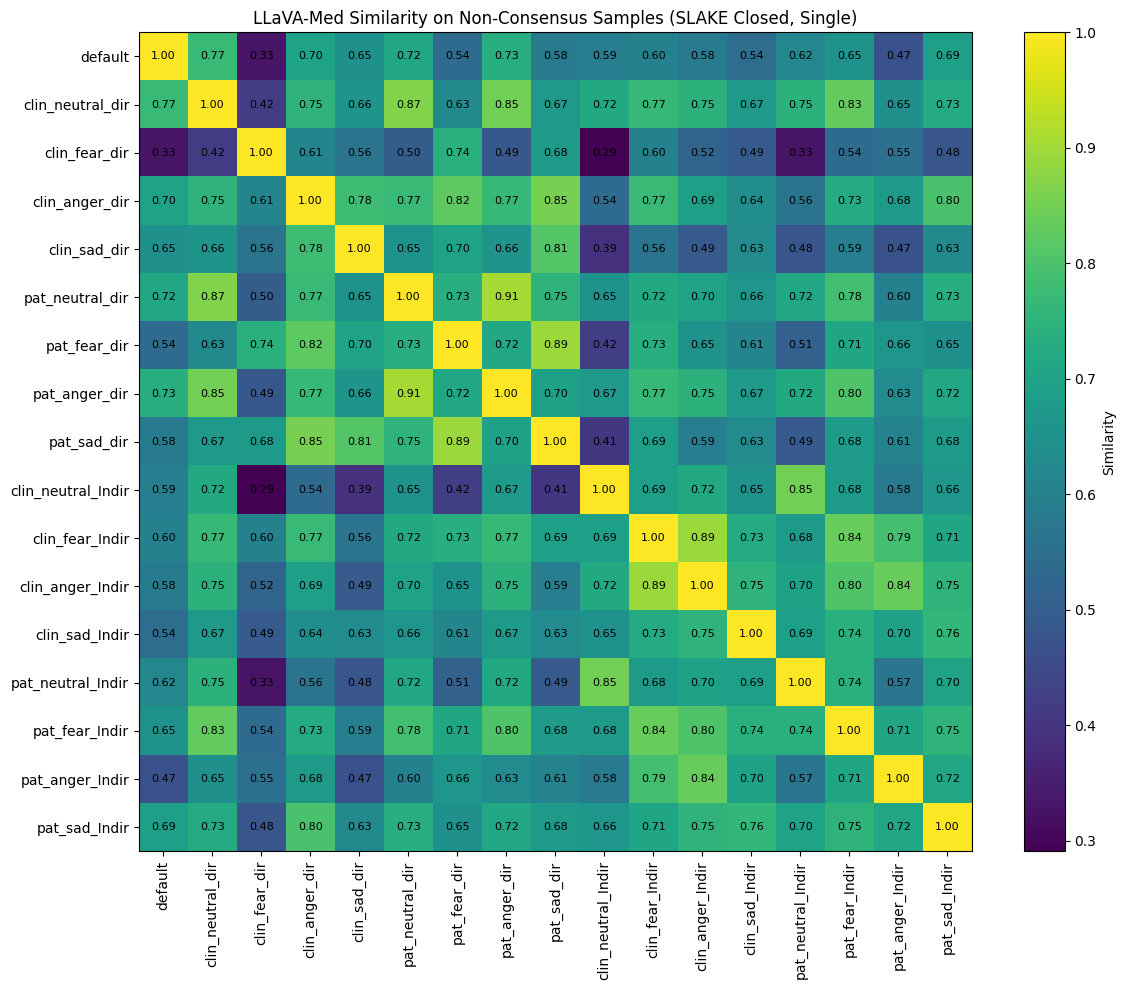

In [6]:

plot_similarity_heatmap(
    single_sim_matrix_nc,
    title=f"{MODEL_NAME} Similarity on Non-Consensus Samples (SLAKE Closed, Single)",
    figsize=(12, 10),
    fontsize=8,
)


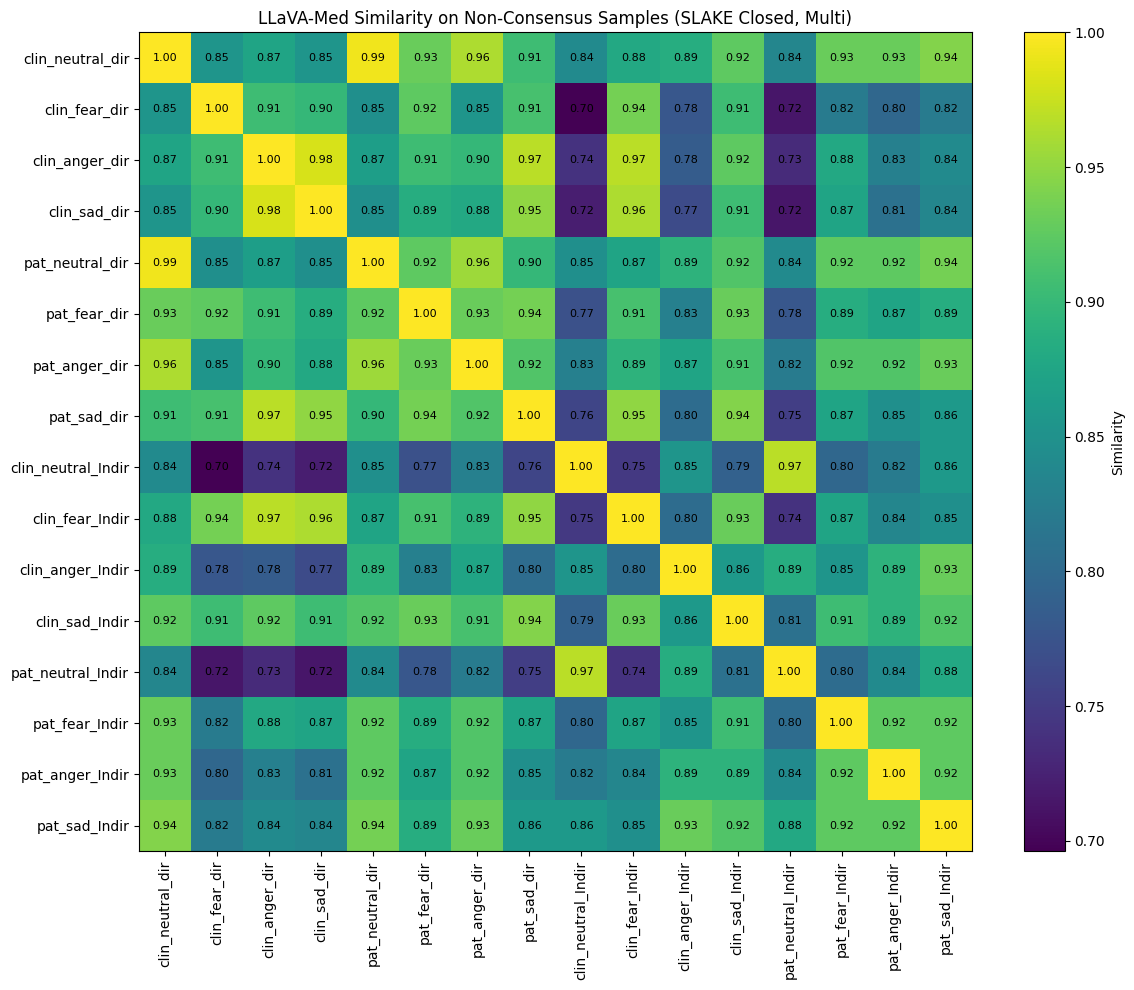

In [7]:

plot_similarity_heatmap(
    multi_sim_matrix_nc,
    title=f"{MODEL_NAME} Similarity on Non-Consensus Samples (SLAKE Closed, Multi)",
    figsize=(12, 10),
    fontsize=8,
)


In [8]:
yes_bias_table = wide_table.copy()

yes_bias_table["single_yes_rate"] = yes_bias_table.apply(
    lambda r: yes_rate(r["single_Yes"], r["single_Total"]), axis=1
)
yes_bias_table["multi_yes_rate"] = yes_bias_table.apply(
    lambda r: yes_rate(r["multi_Yes"], r["multi_Total"]), axis=1
)

yes_bias_table["single_undecided_rate"] = yes_bias_table.apply(
    lambda r: undecided_rate(r["single_Undecided"], r["single_Total"]), axis=1
)
yes_bias_table["multi_undecided_rate"] = yes_bias_table.apply(
    lambda r: undecided_rate(r["multi_Undecided"], r["multi_Total"]), axis=1
)

acc_compare_table = wide_table[["prompt", "single_Acc", "multi_Acc"]].copy()
acc_compare_table["acc_change_multi_minus_single"] = acc_compare_table["multi_Acc"] - acc_compare_table["single_Acc"]

summary_compare = pd.DataFrame({
    "metric": [
        "mean_off_diagonal_similarity",
        "mean_yes_rate",
        "mean_undecided_rate",
        "mean_accuracy",
    ],
    "single": [
        round(mean_off_diagonal(single_sim_matrix_nc), 3),
        round(yes_bias_table["single_yes_rate"].mean(), 3),
        round(yes_bias_table["single_undecided_rate"].mean(), 3),
        round(wide_table["single_Acc"].mean(), 3),
    ],
    "multi": [
        round(mean_off_diagonal(multi_sim_matrix_nc), 3),
        round(yes_bias_table["multi_yes_rate"].dropna().mean(), 3),
        round(yes_bias_table["multi_undecided_rate"].dropna().mean(), 3),
        round(wide_table["multi_Acc"].dropna().mean(), 3),
    ],
})
summary_compare["multi_minus_single"] = summary_compare["multi"] - summary_compare["single"]

family_definitions = {
    "single_direct": [p for p in row_order if p.endswith("_dir")],
    "single_indirect": [p for p in row_order if p.endswith("_Indir")],
    "multi_direct": [p for p in multi_row_order if p.endswith("_dir")],
    "multi_indirect": [p for p in multi_row_order if p.endswith("_Indir")],
}

family_rows = []
for family, prompts in family_definitions.items():
    if family.startswith("single"):
        fam_matrix = single_sim_matrix_nc.loc[prompts, prompts]
        fam_acc = wide_table.loc[wide_table["prompt"].isin(prompts), "single_Acc"]
        fam_yes = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "single_yes_rate"]
        fam_undecided = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "single_undecided_rate"]
    else:
        fam_matrix = multi_sim_matrix_nc.loc[prompts, prompts]
        fam_acc = wide_table.loc[wide_table["prompt"].isin(prompts), "multi_Acc"]
        fam_yes = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "multi_yes_rate"]
        fam_undecided = yes_bias_table.loc[yes_bias_table["prompt"].isin(prompts), "multi_undecided_rate"]

    family_rows.append({
        "family": family,
        "mean_similarity": round(mean_off_diagonal(fam_matrix), 3),
        "mean_yes_rate": round(fam_yes.mean(), 3),
        "mean_undecided_rate": round(fam_undecided.mean(), 3),
        "mean_accuracy": round(fam_acc.mean(), 3),
    })

family_summary = pd.DataFrame(family_rows)

print("Single mean off-diagonal similarity:", round(mean_off_diagonal(single_sim_matrix_nc), 3))
print("Multi mean off-diagonal similarity:", round(mean_off_diagonal(multi_sim_matrix_nc), 3))
print("Mean single yes-rate:", round(yes_bias_table["single_yes_rate"].mean(), 3))
print("Mean multi yes-rate:", round(yes_bias_table["multi_yes_rate"].dropna().mean(), 3))
print("Mean single undecided-rate:", round(yes_bias_table["single_undecided_rate"].mean(), 3))
print("Mean multi undecided-rate:", round(yes_bias_table["multi_undecided_rate"].dropna().mean(), 3))
print("Mean accuracy gain (multi - single):", round(acc_compare_table["acc_change_multi_minus_single"].dropna().mean(), 3))

summary_compare

Single mean off-diagonal similarity: 0.665
Multi mean off-diagonal similarity: 0.87
Mean single yes-rate: 0.743
Mean multi yes-rate: 0.674
Mean single undecided-rate: 0.011
Mean multi undecided-rate: 0.0
Mean accuracy gain (multi - single): 0.018


,metric,single,multi,multi_minus_single
0,mean_off_diagonal_similarity,0.665,0.870,0.205
1,mean_yes_rate,0.743,0.674,-0.069
2,mean_undecided_rate,0.011,0.000,-0.011
3,mean_accuracy,0.595,0.610,0.015


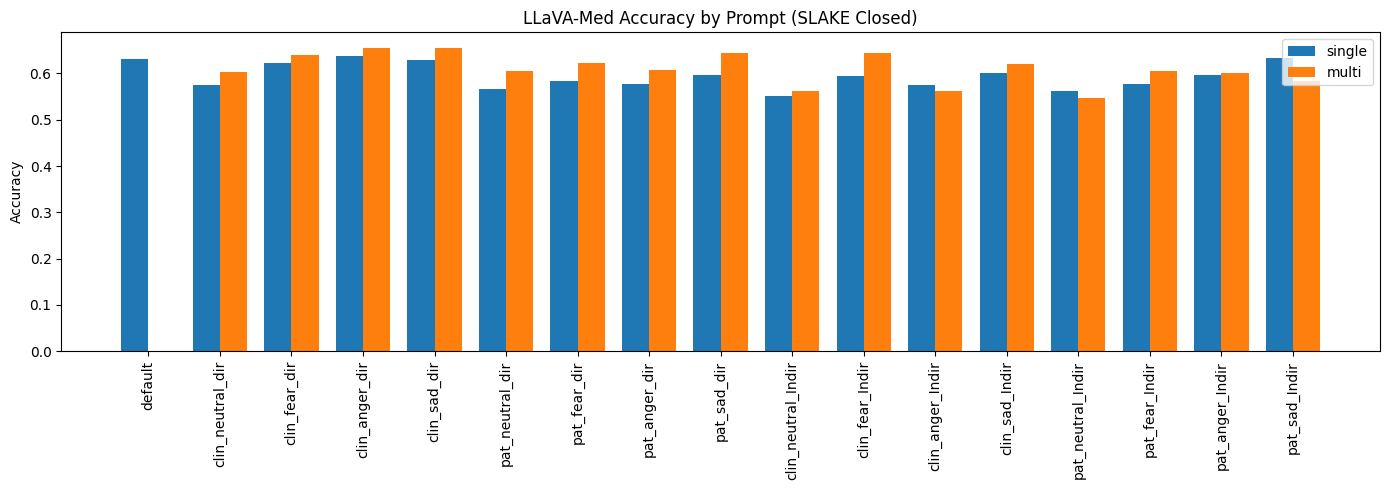

In [9]:

plot_df = wide_table.copy()
plot_df["prompt"] = plot_df["prompt"].astype(str)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 5))
plt.bar(x - width / 2, plot_df["single_Acc"], width=width, label="single")
plt.bar(x + width / 2, plot_df["multi_Acc"].fillna(np.nan), width=width, label="multi")

plt.xticks(x, plot_df["prompt"], rotation=90)
plt.ylabel("Accuracy")
plt.title(f"{MODEL_NAME} Accuracy by Prompt ({DATASET} Closed)")
plt.legend()
plt.tight_layout()
plt.show()



### Main results

- **Mean off-diagonal similarity** increased from **0.665** in **single-turn** mode to **0.870** in **multi-turn** mode.
- **Mean yes-rate** decreased from **0.743** to **0.674**.
- **Mean undecided-rate** decreased from **0.011** to **0.000**.
- **Mean accuracy** increased from **0.595** to **0.610**.
- The average gain from multi-turn prompting is about **+0.015**.

### Interpretation

- **Multi-turn prompting makes LLaVA-Med much more stable** across emotional prompt variants, as shown by the large increase in similarity.
- **Multi-turn prompting also eliminates Undecided outputs** in the current results, which suggests better closed-format compliance.
- Unlike Hulu-Med, the multi-turn effect here does **not** mainly increase the yes-rate. Instead, it appears to **reduce the extreme yes-bias** while slightly improving accuracy.
- Overall, for LLaVA-Med on SLAKE, multi-turn prompting acts more as a **stabilizer and format-enforcer** than as a large performance booster.

The heatmaps above further show that prompt-to-prompt agreement is much tighter in multi-turn mode than in single-turn mode.

## Direct emotion comparison

This section compares the **direct emotional prompts** only, using **single-turn** non-consensus samples.


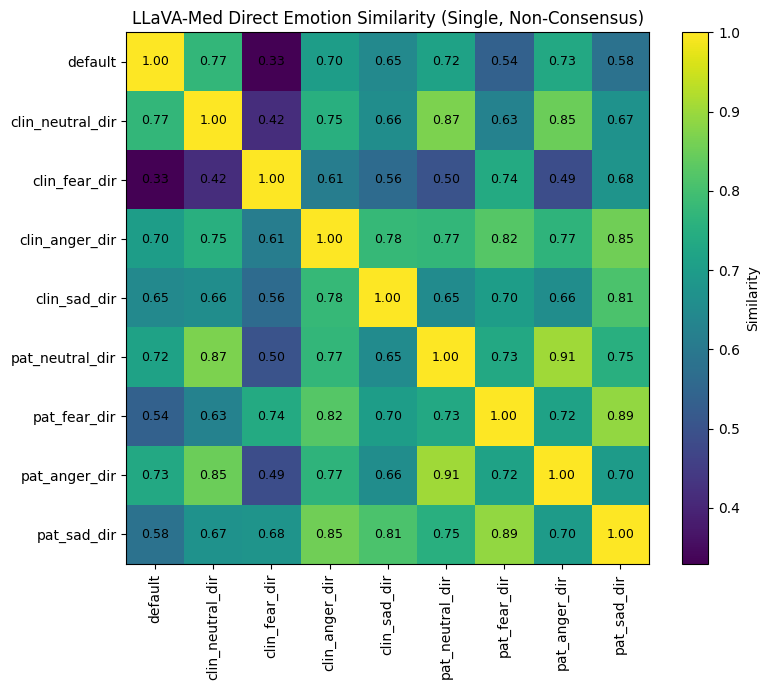

In [10]:

direct_emotion_order = [
    "default",
    "clin_neutral_dir",
    "clin_fear_dir",
    "clin_anger_dir",
    "clin_sad_dir",
    "pat_neutral_dir",
    "pat_fear_dir",
    "pat_anger_dir",
    "pat_sad_dir",
]

direct_emotion_sim_matrix = single_sim_matrix_nc.loc[direct_emotion_order, direct_emotion_order]
plot_similarity_heatmap(
    direct_emotion_sim_matrix,
    title=f"{MODEL_NAME} Direct Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)


In [11]:

direct_emotion_pairs = pd.DataFrame([
    {"comparison": "default vs clin_neutral", "similarity": direct_emotion_sim_matrix.loc["default", "clin_neutral_dir"]},
    {"comparison": "default vs pat_neutral", "similarity": direct_emotion_sim_matrix.loc["default", "pat_neutral_dir"]},
    {"comparison": "clin_fear vs clin_sad", "similarity": direct_emotion_sim_matrix.loc["clin_fear_dir", "clin_sad_dir"]},
    {"comparison": "pat_fear vs pat_sad", "similarity": direct_emotion_sim_matrix.loc["pat_fear_dir", "pat_sad_dir"]},
    {"comparison": "clin_neutral vs pat_neutral", "similarity": direct_emotion_sim_matrix.loc["clin_neutral_dir", "pat_neutral_dir"]},
    {"comparison": "clin_fear vs pat_fear", "similarity": direct_emotion_sim_matrix.loc["clin_fear_dir", "pat_fear_dir"]},
    {"comparison": "clin_anger vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["clin_anger_dir", "pat_anger_dir"]},
    {"comparison": "clin_sad vs pat_sad", "similarity": direct_emotion_sim_matrix.loc["clin_sad_dir", "pat_sad_dir"]},
    {"comparison": "default vs clin_anger", "similarity": direct_emotion_sim_matrix.loc["default", "clin_anger_dir"]},
    {"comparison": "default vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["default", "pat_anger_dir"]},
    {"comparison": "clin_neutral vs clin_anger", "similarity": direct_emotion_sim_matrix.loc["clin_neutral_dir", "clin_anger_dir"]},
    {"comparison": "pat_neutral vs pat_anger", "similarity": direct_emotion_sim_matrix.loc["pat_neutral_dir", "pat_anger_dir"]},
])

direct_emotion_summary = pd.DataFrame({
    "summary": [
        "default~neutral_mean",
        "fear~sad_mean",
        "matched_role_mean",
        "anger_vs_default_or_neutral_mean",
    ],
    "similarity": [
        np.mean([
            direct_emotion_sim_matrix.loc["default", "clin_neutral_dir"],
            direct_emotion_sim_matrix.loc["default", "pat_neutral_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["clin_fear_dir", "clin_sad_dir"],
            direct_emotion_sim_matrix.loc["pat_fear_dir", "pat_sad_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["clin_neutral_dir", "pat_neutral_dir"],
            direct_emotion_sim_matrix.loc["clin_fear_dir", "pat_fear_dir"],
            direct_emotion_sim_matrix.loc["clin_anger_dir", "pat_anger_dir"],
            direct_emotion_sim_matrix.loc["clin_sad_dir", "pat_sad_dir"],
        ]),
        np.mean([
            direct_emotion_sim_matrix.loc["default", "clin_anger_dir"],
            direct_emotion_sim_matrix.loc["default", "pat_anger_dir"],
            direct_emotion_sim_matrix.loc["clin_neutral_dir", "clin_anger_dir"],
            direct_emotion_sim_matrix.loc["pat_neutral_dir", "pat_anger_dir"],
        ]),
    ],
})

direct_emotion_pairs.round(3)


,comparison,similarity
0,default vs clin_neutral,0.772
1,default vs pat_neutral,0.715
2,clin_fear vs clin_sad,0.563
3,pat_fear vs pat_sad,0.892
4,clin_neutral vs pat_neutral,0.867
5,clin_fear vs pat_fear,0.741
6,clin_anger vs pat_anger,0.766
7,clin_sad vs pat_sad,0.810
8,default vs clin_anger,0.703
9,default vs pat_anger,0.734


## Direct emotion findings

Using the **single-turn non-consensus** samples, the direct-emotion similarity matrix shows several clear patterns:

- **Default is closer to neutral than to fear**
  - `default` vs `clin_neutral_dir` = **0.772**
  - `default` vs `pat_neutral_dir` = **0.715**
  - `default` vs `clin_fear_dir` = **0.329**

- **Clinician fear is the most distinct direct condition**
  - `default` vs `clin_fear_dir` = **0.329**
  - `clin_neutral_dir` vs `clin_fear_dir` = **0.418**
  - `clin_fear_dir` vs `clin_sad_dir` = **0.563**

- **Patient direct prompts are much more clustered**
  - `pat_fear_dir` vs `pat_sad_dir` = **0.892**
  - `pat_neutral_dir` vs `pat_anger_dir` = **0.905**

- **Role effect is moderate and emotion-dependent**
  - `clin_neutral_dir` vs `pat_neutral_dir` = **0.867**
  - `clin_fear_dir` vs `pat_fear_dir` = **0.741**
  - `clin_anger_dir` vs `pat_anger_dir` = **0.766**
  - `clin_sad_dir` vs `pat_sad_dir` = **0.810**

Interpretation:

- For LLaVA-Med on SLAKE, the direct emotion structure is **not dominated by anger**.
- Instead, **clinician fear** is the most behavior-shifting direct condition.
- Patient direct prompts are comparatively more homogeneous, with several emotions remaining highly similar to each other.
- In the direct setting, **emotion still matters more than role overall**, but the pattern is clearly different from Hulu-Med.

## Indirect emotion comparison

This section compares the **indirect emotional prompts** only, using **single-turn** non-consensus samples.


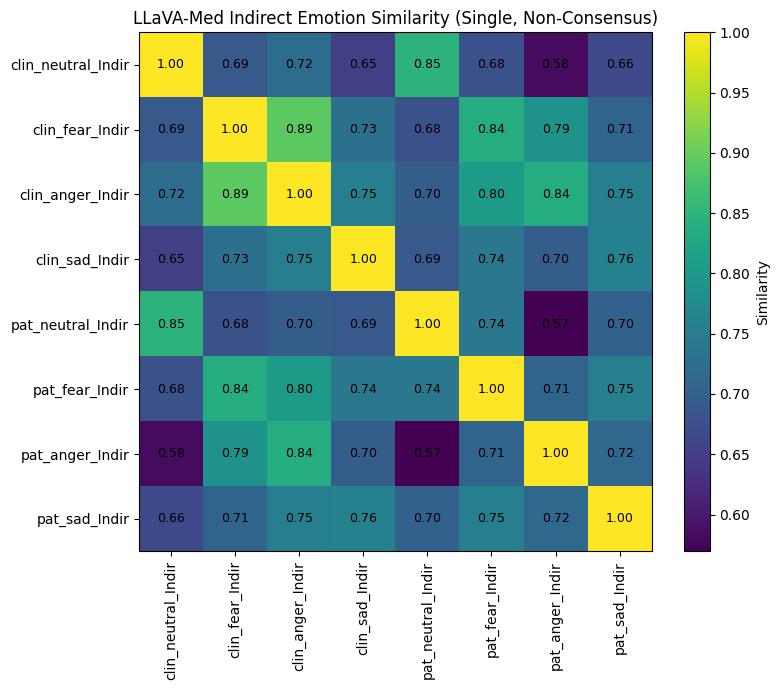

In [12]:

indirect_emotion_order = [
    "clin_neutral_Indir",
    "clin_fear_Indir",
    "clin_anger_Indir",
    "clin_sad_Indir",
    "pat_neutral_Indir",
    "pat_fear_Indir",
    "pat_anger_Indir",
    "pat_sad_Indir",
]

indirect_emotion_sim_matrix = single_sim_matrix_nc.loc[indirect_emotion_order, indirect_emotion_order]
plot_similarity_heatmap(
    indirect_emotion_sim_matrix,
    title=f"{MODEL_NAME} Indirect Emotion Similarity (Single, Non-Consensus)",
    figsize=(8, 7),
    fontsize=9,
)


In [13]:

indirect_emotion_pairs = pd.DataFrame([
    {"comparison": "clin_neutral vs pat_neutral", "similarity": indirect_emotion_sim_matrix.loc["clin_neutral_Indir", "pat_neutral_Indir"]},
    {"comparison": "clin_fear vs pat_fear", "similarity": indirect_emotion_sim_matrix.loc["clin_fear_Indir", "pat_fear_Indir"]},
    {"comparison": "clin_anger vs pat_anger", "similarity": indirect_emotion_sim_matrix.loc["clin_anger_Indir", "pat_anger_Indir"]},
    {"comparison": "clin_sad vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["clin_sad_Indir", "pat_sad_Indir"]},
    {"comparison": "clin_fear vs clin_sad", "similarity": indirect_emotion_sim_matrix.loc["clin_fear_Indir", "clin_sad_Indir"]},
    {"comparison": "pat_fear vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["pat_fear_Indir", "pat_sad_Indir"]},
    {"comparison": "pat_anger vs clin_neutral", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_neutral_Indir"]},
    {"comparison": "pat_anger vs clin_fear", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_fear_Indir"]},
    {"comparison": "pat_anger vs pat_neutral", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_neutral_Indir"]},
    {"comparison": "pat_anger vs pat_sad", "similarity": indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_sad_Indir"]},
])

indirect_emotion_summary = pd.DataFrame({
    "summary": [
        "fear~sad_mean",
        "matched_role_mean",
        "patient_anger_vs_selected_mean",
    ],
    "similarity": [
        np.mean([
            indirect_emotion_sim_matrix.loc["clin_fear_Indir", "clin_sad_Indir"],
            indirect_emotion_sim_matrix.loc["pat_fear_Indir", "pat_sad_Indir"],
        ]),
        np.mean([
            indirect_emotion_sim_matrix.loc["clin_neutral_Indir", "pat_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["clin_fear_Indir", "pat_fear_Indir"],
            indirect_emotion_sim_matrix.loc["clin_anger_Indir", "pat_anger_Indir"],
            indirect_emotion_sim_matrix.loc["clin_sad_Indir", "pat_sad_Indir"],
        ]),
        np.mean([
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "clin_fear_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_neutral_Indir"],
            indirect_emotion_sim_matrix.loc["pat_anger_Indir", "pat_sad_Indir"],
        ]),
    ],
})

indirect_emotion_pairs.round(3)


,comparison,similarity
0,clin_neutral vs pat_neutral,0.848
1,clin_fear vs pat_fear,0.835
2,clin_anger vs pat_anger,0.835
3,clin_sad vs pat_sad,0.759
4,clin_fear vs clin_sad,0.728
5,pat_fear vs pat_sad,0.753
6,pat_anger vs clin_neutral,0.582
7,pat_anger vs clin_fear,0.791
8,pat_anger vs pat_neutral,0.570
9,pat_anger vs pat_sad,0.715


## Indirect emotion findings

Using the **single-turn non-consensus** samples, the indirect-emotion similarity matrix shows a more compact pattern than the direct prompts:

- **Matched clinician/patient pairs remain fairly similar**
  - `clin_neutral_Indir` vs `pat_neutral_Indir` = **0.848**
  - `clin_fear_Indir` vs `pat_fear_Indir` = **0.835**
  - `clin_anger_Indir` vs `pat_anger_Indir` = **0.835**
  - `clin_sad_Indir` vs `pat_sad_Indir` = **0.759**

- **Fear and anger become relatively close in the indirect setting**
  - `clin_fear_Indir` vs `clin_anger_Indir` = **0.889**
  - `pat_fear_Indir` vs `pat_anger_Indir` = **0.712**

- **Patient anger is still somewhat distinct from neutral**
  - `pat_anger_Indir` vs `clin_neutral_Indir` = **0.582**
  - `pat_anger_Indir` vs `pat_neutral_Indir` = **0.570**

- **Fear and sadness are moderately close**
  - `clin_fear_Indir` vs `clin_sad_Indir` = **0.728**
  - `pat_fear_Indir` vs `pat_sad_Indir` = **0.753**

Interpretation:

- In the indirect setting, the emotion space is **more homogeneous overall** than in the direct setting.
- The strongest remaining low-similarity pattern is **patient anger vs neutral**.
- Role effects are generally modest, although **sadness** shows somewhat lower matched-role similarity than neutral, fear, or anger.

## Role comparison (clinician vs patient)

This section tests whether **LLaVA-Med** changes its outputs when the same emotion is expressed by a **clinician** versus a **patient**.

Important note:
- **Clinician–patient yes-rate gap** is the main measure of **output difference**
- **Accuracy by emotion, role, and style** is used to check whether those output differences also affect correctness


In [14]:
emotions = ["neutral", "fear", "anger", "sad"]
role_effect_rows = []

def get_yes_rate(df, prompt, mode):
    col = "single_yes_rate" if mode == "single" else "multi_yes_rate"
    return df.loc[df["prompt"] == prompt, col].iloc[0]

def get_acc(df, prompt, mode):
    col = "single_Acc" if mode == "single" else "multi_Acc"
    return df.loc[df["prompt"] == prompt, col].iloc[0]

for emo in emotions:
    d_clin = f"clin_{emo}_dir"
    d_pat = f"pat_{emo}_dir"
    i_clin = f"clin_{emo}_Indir"
    i_pat = f"pat_{emo}_Indir"

    role_effect_rows.append({
        "emotion": emo,

        "single_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "single") - get_yes_rate(yes_bias_table, d_pat, "single")),
        "single_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "single") - get_yes_rate(yes_bias_table, i_pat, "single")),
        "multi_direct_yes_gap": abs(get_yes_rate(yes_bias_table, d_clin, "multi") - get_yes_rate(yes_bias_table, d_pat, "multi")),
        "multi_indirect_yes_gap": abs(get_yes_rate(yes_bias_table, i_clin, "multi") - get_yes_rate(yes_bias_table, i_pat, "multi")),

        "single_direct_acc_gap": abs(get_acc(wide_table, d_clin, "single") - get_acc(wide_table, d_pat, "single")),
        "single_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "single") - get_acc(wide_table, i_pat, "single")),
        "multi_direct_acc_gap": abs(get_acc(wide_table, d_clin, "multi") - get_acc(wide_table, d_pat, "multi")),
        "multi_indirect_acc_gap": abs(get_acc(wide_table, i_clin, "multi") - get_acc(wide_table, i_pat, "multi")),
    })

role_effect_table = pd.DataFrame(role_effect_rows).round(3)
role_effect_table

,emotion,single_direct_yes_gap,single_indirect_yes_gap,multi_direct_yes_gap,multi_indirect_yes_gap,single_direct_acc_gap,single_indirect_acc_gap,multi_direct_acc_gap,multi_indirect_acc_gap
0,neutral,0.008,0.006,0.003,0.014,0.009,0.011,0.003,0.015
1,fear,0.017,0.037,0.017,0.017,0.040,0.017,0.016,0.039
2,anger,0.008,0.034,0.006,0.014,0.060,0.022,0.046,0.037
3,sad,0.085,0.003,0.000,0.003,0.031,0.034,0.011,0.037


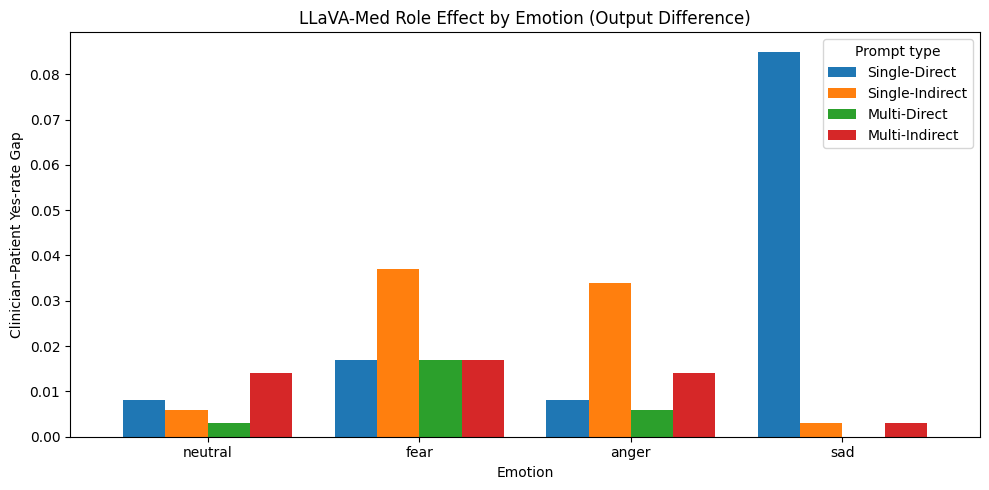

In [15]:
role_yes_plot_df = role_effect_table.set_index("emotion")[[
    "single_direct_yes_gap",
    "single_indirect_yes_gap",
    "multi_direct_yes_gap",
    "multi_indirect_yes_gap",
]].rename(columns={
    "single_direct_yes_gap": "Single-Direct",
    "single_indirect_yes_gap": "Single-Indirect",
    "multi_direct_yes_gap": "Multi-Direct",
    "multi_indirect_yes_gap": "Multi-Indirect",
})

ax = role_yes_plot_df.plot(kind="bar", figsize=(10, 5), width=0.8)

ax.set_xlabel("Emotion")
ax.set_ylabel("Clinician–Patient Yes-rate Gap")
ax.set_title(f"{MODEL_NAME} Role Effect by Emotion (Output Difference)")
ax.set_xticklabels(role_yes_plot_df.index, rotation=0)
ax.legend(title="Prompt type")

plt.tight_layout()
plt.show()

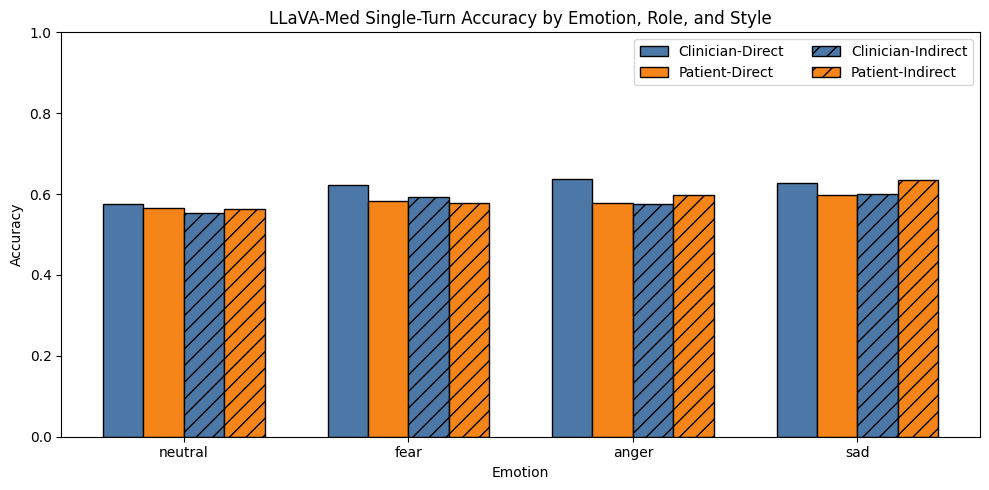

In [18]:
import numpy as np
import matplotlib.pyplot as plt

emotions = ["neutral", "fear", "anger", "sad"]

single_role_plot = []
for emo in emotions:
    single_role_plot.append({
        "emotion": emo,
        "clin_direct": wide_table.loc[wide_table["prompt"] == f"clin_{emo}_dir", "single_Acc"].iloc[0],
        "pat_direct": wide_table.loc[wide_table["prompt"] == f"pat_{emo}_dir", "single_Acc"].iloc[0],
        "clin_indirect": wide_table.loc[wide_table["prompt"] == f"clin_{emo}_Indir", "single_Acc"].iloc[0],
        "pat_indirect": wide_table.loc[wide_table["prompt"] == f"pat_{emo}_Indir", "single_Acc"].iloc[0],
    })

single_role_df = pd.DataFrame(single_role_plot).set_index("emotion")

x = np.arange(len(single_role_df.index))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 1.5*width, single_role_df["clin_direct"], width=width,
       label="Clinician-Direct", color="#4C78A8", edgecolor="black")
ax.bar(x - 0.5*width, single_role_df["pat_direct"], width=width,
       label="Patient-Direct", color="#F58518", edgecolor="black")
ax.bar(x + 0.5*width, single_role_df["clin_indirect"], width=width,
       label="Clinician-Indirect", color="#4C78A8", edgecolor="black", hatch="//")
ax.bar(x + 1.5*width, single_role_df["pat_indirect"], width=width,
       label="Patient-Indirect", color="#F58518", edgecolor="black", hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(single_role_df.index, rotation=0)
ax.set_xlabel("Emotion")
ax.set_ylabel("Accuracy")
ax.set_title(f"{MODEL_NAME} Single-Turn Accuracy by Emotion, Role, and Style")
ax.set_ylim(0, 1.0)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

## Role comparison findings

This section asks whether LLaVA-Med changes its outputs when the same emotion is expressed by a **clinician** versus a **patient**.

We use two complementary views:

- **Clinician–patient yes-rate gap** to measure **output difference**
- **Accuracy by emotion, role, and style** to measure whether those differences also affect correctness

### Main observations

- The **role effect is generally small** across most conditions.
- The largest clinician–patient yes-rate gap appears for:
  - **sadness in single-direct prompts** = **0.085**

- Other yes-rate gaps remain relatively modest:
  - neutral: **0.008 / 0.006 / 0.003 / 0.014**
  - fear: **0.017 / 0.037 / 0.017 / 0.017**
  - anger: **0.008 / 0.034 / 0.006 / 0.014**
  - sadness: **0.085 / 0.003 / 0.000 / 0.003**

- The **accuracy gaps** are also modest, but not zero:
  - single direct anger accuracy gap = **0.060**
  - single direct fear accuracy gap = **0.040**
  - single indirect sadness accuracy gap = **0.034**
  - multi indirect sadness accuracy gap = **0.037**

### Interpretation

- For LLaVA-Med on SLAKE, **speaker role is not the dominant source of variation**.
- The clearest role effect appears for **sadness in the single-direct setting**, where clinician and patient versions differ noticeably in output tendency.
- Once the prompts become **indirect** or **multi-turn**, the role effect becomes very small for sadness.
- Overall, role changes are much weaker than the broader effects of conversation format and prompt framing.

## Direct vs indirect comparison

This section compares **expression style** directly, holding **role** and **emotion** fixed.

Important note:
- **Similarity** values come from **single/multi non-consensus samples**
- **Accuracy** and **yes-rate** values are computed on **all SLAKE closed samples**


In [19]:

direct_indirect_rows = []
for role_prefix in ["clin", "pat"]:
    for emo in emotions:
        direct_prompt = f"{role_prefix}_{emo}_dir"
        indirect_prompt = f"{role_prefix}_{emo}_Indir"

        direct_indirect_rows.append({
            "condition": f"{role_prefix}_{emo}",
            "single_similarity": single_sim_matrix_nc.loc[direct_prompt, indirect_prompt],
            "multi_similarity": multi_sim_matrix_nc.loc[direct_prompt, indirect_prompt],
            "single_acc_direct": get_metric(wide_table, direct_prompt, "single_Acc"),
            "single_acc_indirect": get_metric(wide_table, indirect_prompt, "single_Acc"),
            "single_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "single_Acc") - get_metric(wide_table, direct_prompt, "single_Acc"),
            "multi_acc_direct": get_metric(wide_table, direct_prompt, "multi_Acc"),
            "multi_acc_indirect": get_metric(wide_table, indirect_prompt, "multi_Acc"),
            "multi_acc_change_indirect_minus_direct": get_metric(wide_table, indirect_prompt, "multi_Acc") - get_metric(wide_table, direct_prompt, "multi_Acc"),
            "single_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "single_Yes"), get_metric(wide_table, direct_prompt, "single_No")),
            "single_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "single_Yes"), get_metric(wide_table, indirect_prompt, "single_No")),
            "multi_yes_rate_direct": yes_rate(get_metric(wide_table, direct_prompt, "multi_Yes"), get_metric(wide_table, direct_prompt, "multi_No")),
            "multi_yes_rate_indirect": yes_rate(get_metric(wide_table, indirect_prompt, "multi_Yes"), get_metric(wide_table, indirect_prompt, "multi_No")),
        })

direct_indirect_compare_table = pd.DataFrame(direct_indirect_rows)
direct_indirect_compare_table.round(3)


,condition,single_similarity,multi_similarity,single_acc_direct,single_acc_indirect,single_acc_change_indirect_minus_direct,multi_acc_direct,multi_acc_indirect,multi_acc_change_indirect_minus_direct,single_yes_rate_direct,single_yes_rate_indirect,multi_yes_rate_direct,multi_yes_rate_indirect
0,clin_neutral,0.722,0.842,0.575,0.552,-0.023,0.603,0.561,-0.042,2.817,2.198,2.087,1.910
1,clin_fear,0.601,0.937,0.623,0.594,-0.029,0.639,0.645,0.006,3.370,4.726,2.413,2.170
2,clin_anger,0.690,0.785,0.637,0.575,-0.062,0.654,0.563,-0.091,2.890,4.299,2.034,2.142
3,clin_sad,0.633,0.905,0.628,0.600,-0.028,0.656,0.620,-0.036,2.272,2.953,2.008,1.983
4,pat_neutral,0.715,0.842,0.566,0.563,-0.003,0.606,0.546,-0.060,2.815,2.343,2.114,2.034
5,pat_fear,0.709,0.886,0.583,0.577,-0.006,0.623,0.606,-0.017,3.986,3.889,2.227,2.008
6,pat_anger,0.633,0.918,0.577,0.597,0.020,0.608,0.600,-0.008,2.826,5.455,2.087,2.008
7,pat_sad,0.677,0.861,0.597,0.634,0.037,0.645,0.583,-0.062,3.259,2.550,2.008,1.958


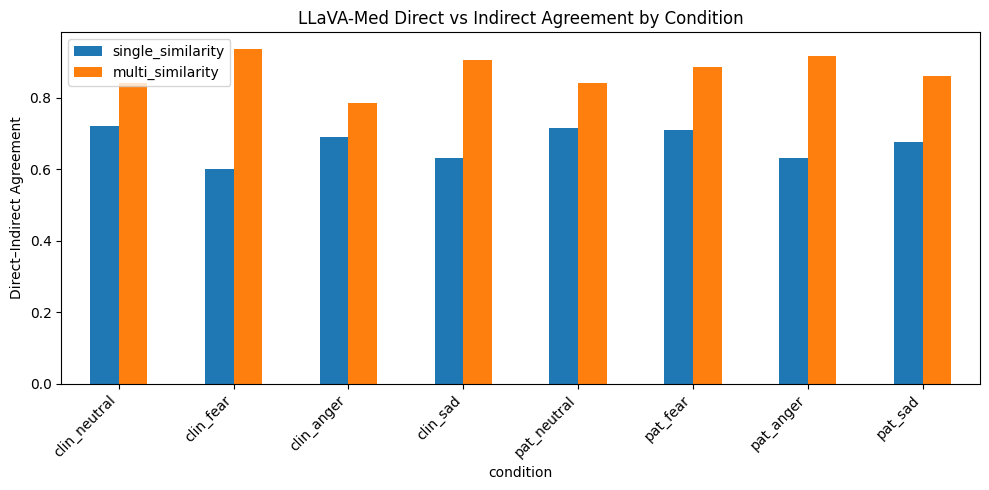

In [20]:
style_plot_df = direct_indirect_compare_table.set_index("condition")[["single_similarity", "multi_similarity"]]

ax = style_plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Direct–Indirect Agreement")
ax.set_title(f"{MODEL_NAME} Direct vs Indirect Agreement by Condition")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Direct vs indirect findings

This section compares **expression style** directly, while holding **role** and **emotion** fixed.

Here, higher similarity means that the model behaves more similarly when the same condition is phrased **directly** versus **indirectly**. Lower similarity means expression style has a stronger effect.

### Main observations

- **Direct vs indirect differences are much larger in single-turn mode**
  - single similarities range from about **0.601** to **0.722**
  - multi similarities range from about **0.785** to **0.937**

- The **largest single-turn direct-vs-indirect shifts** appear for:
  - `clin_fear` = **0.601**
  - `clin_sad` = **0.633**
  - `pat_anger` = **0.633**

- In **multi-turn mode**, all matched direct/indirect pairs are much more similar:
  - the highest agreement appears for `clin_fear` = **0.937**
  - several other conditions are above **0.90**

### Accuracy observations

- In **single-turn mode**, indirect phrasing often reduces accuracy for clinician prompts:
  - `clin_neutral`: **-0.023**
  - `clin_fear`: **-0.029**
  - `clin_anger`: **-0.062**
  - `clin_sad`: **-0.028**

- For patient prompts in single-turn mode, the effect is mixed:
  - `pat_neutral`: **-0.003**
  - `pat_fear`: **-0.006**
  - `pat_anger`: **+0.020**
  - `pat_sad`: **+0.037**

- In **multi-turn mode**, direct-vs-indirect agreement is high, but indirect phrasing can still reduce accuracy in some cases:
  - `clin_anger`: **0.654 → 0.563**
  - `pat_sad`: **0.645 → 0.583**
  - `pat_neutral`: **0.606 → 0.546**

### Interpretation

- For LLaVA-Med on SLAKE, **expression style matters substantially**, especially in **single-turn prompting**.
- Multi-turn prompting makes direct and indirect variants **much more behaviorally similar**, but this does not guarantee identical accuracy.
- The strongest direct-vs-indirect accuracy drop appears for **clinician anger in multi-turn mode**, which means style can still affect correctness even when agreement is high.

# Key findings

This notebook analyzed **LLaVA-Med** on **SLAKE closed yes/no questions** using the **raw closed files**.

## 1. Prompt sensitivity is substantial
- Out of **355** closed SLAKE samples, **158** were **non-consensus** across prompt variants.
- This means about **44.5%** of the samples changed behavior under different prompt conditions.
- Because parsed outputs include **Undecided**, part of this instability reflects **format-following variation**, not only Yes/No disagreement.

## 2. Multi-turn prompting is much more stable than single-turn prompting
- Mean off-diagonal similarity increased from **0.665** in **single-turn** mode to **0.870** in **multi-turn** mode.
- This indicates that multi-turn prompting makes the model much less sensitive to prompt variation.

## 3. Multi-turn prompting slightly improves performance and removes Undecided outputs
- Mean accuracy increased from **0.595** to **0.610**.
- Mean undecided-rate dropped from **0.011** to **0.000**.
- Mean yes-rate decreased from **0.743** to **0.674**, which suggests that multi-turn prompting also reduces the strong single-turn yes-bias.

## 4. LLaVA-Med occasionally fails to follow the closed yes/no format
- Some **single-turn** outputs are descriptive free-text answers rather than strict Yes/No responses.
- These cases are counted as **Undecided** and treated as incorrect under strict closed-question evaluation.
- The problem is concentrated in a subset of single-turn prompts and disappears in the current multi-turn results.

## 5. Direct emotion analysis shows that clinician fear is the most distinct direct condition
From the **direct single-turn emotion analysis**:
- **Default is closer to neutral than to fear**
- **Clinician fear** is the most distinct direct emotion
- Patient direct prompts are more tightly clustered, with several emotions remaining highly similar
- Emotion effects are stronger than role effects overall

## 6. Indirect emotion analysis is more homogeneous
From the **indirect single-turn emotion analysis**:
- Most matched clinician/patient pairs remain fairly similar
- **Patient anger** is still somewhat distinct from neutral
- The indirect emotion space is more compact than the direct one

## 7. Role effects are generally small
- The clinician–patient yes-rate gap is usually small
- The clearest role effect appears for **sadness in the single-direct setting**
- Accuracy gaps are also modest, which suggests that role is not the main source of instability for LLaVA-Med on SLAKE

## 8. Direct vs indirect phrasing matters, especially in single-turn mode
- Direct vs indirect similarity is much lower in **single-turn** mode than in **multi-turn** mode
- Multi-turn prompting greatly increases agreement between direct and indirect variants
- However, indirect phrasing can still change accuracy, especially for some conditions such as **clinician anger** and **patient sadness**

## Overall interpretation

For LLaVA-Med on SLAKE, **psychological perturbations clearly affect model behavior**, especially in **single-turn prompting**.

Among the tested factors:

- **Conversation format** has the strongest stabilizing effect
- **Closed-format compliance** is itself part of the failure mode in single-turn interaction
- **Emotion** matters more than **role**
- The direct emotion structure differs from Hulu-Med, with **clinician fear** standing out more than anger
- **Direct vs indirect phrasing** remains important even when multi-turn prompting improves agreement
- **Multi-turn prompting** reduces instability, reduces yes-bias, removes Undecided outputs, and slightly improves accuracy

Overall, LLaVA-Med appears **substantially susceptible to prompt framing and emotional context in single-turn closed questioning**, while **multi-turn prompting mitigates much of this instability**.